# 🛒 Quantium Virtual Experience — Retail Strategy Analysis
**Project:** Chips Category Customer Analysis  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** QVI Purchase Behaviour + Transaction Data  
**Goal:** Identify which customer segments drive chip sales and surface actionable recommendations for the category manager.

---


## 1. 📦 Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#2D6A4F','#40916C','#52B788','#74C69D','#95D5B2','#B7E4C7']
print("✅ Libraries loaded")


✅ Libraries loaded


## 2. 📂 Loading Data

In [ ]:
# ── Update these paths if running locally ──────────────────────────────────
# purchase_df = pd.read_csv('QVI_purchase_behaviour.csv')
# transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

# ── Google Colab ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
purchase_df    = pd.read_csv('/content/drive/MyDrive/quantium forage/QVI_purchase_behaviour.csv')
transaction_df = pd.read_excel('/content/drive/MyDrive/quantium forage/QVI_transaction_data.xlsx')

print(f"Purchase data  : {purchase_df.shape[0]:,} rows × {purchase_df.shape[1]} cols")
print(f"Transaction data: {transaction_df.shape[0]:,} rows × {transaction_df.shape[1]} cols")


Mounted at /content/drive
Purchase data  : 72,637 rows × 3 cols
Transaction data: 264,836 rows × 8 cols


## 3. 🔍 Exploratory Data Analysis

In [ ]:
print("=" * 50)
print("PURCHASE BEHAVIOUR DATASET")
print("=" * 50)
display(purchase_df.head())
print(f"\nShape: {purchase_df.shape}")
print(f"\nNull values:\n{purchase_df.isna().sum()}")
print(f"\nLifestage segments : {purchase_df['LIFESTAGE'].nunique()}")
print(f"Premium categories : {purchase_df['PREMIUM_CUSTOMER'].nunique()}")
print(f"\nLifestage values:\n{purchase_df['LIFESTAGE'].unique()}")
print(f"\nPremium values    : {purchase_df['PREMIUM_CUSTOMER'].unique()}")


PURCHASE BEHAVIOUR DATASET


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream



Shape: (72637, 3)

Null values:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Lifestage segments : 7
Premium categories : 3

Lifestage values:
['YOUNG SINGLES/COUPLES' 'YOUNG FAMILIES' 'OLDER SINGLES/COUPLES'
 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES' 'OLDER FAMILIES' 'RETIREES']

Premium values    : ['Premium' 'Mainstream' 'Budget']


In [ ]:
print("=" * 50)
print("TRANSACTION DATASET")
print("=" * 50)
display(transaction_df.head())
print(f"\nShape: {transaction_df.shape}")
print(f"\nData types:\n{transaction_df.dtypes}")
print(f"\nNull values:\n{transaction_df.isna().sum()}")
print(f"\nBasic stats:")
display(transaction_df.describe())


TRANSACTION DATASET


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8



Shape: (264836, 8)

Data types:
DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

Null values:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

Basic stats:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


## 4. 🧹 Data Preprocessing
### 4.1 Fix Date Column
The DATE column is stored as a numeric Excel serial — we convert it to proper datetime.


In [ ]:
transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D')
transaction_df = transaction_df.sort_values('DATE').reset_index(drop=True)
print(f"Date range: {transaction_df['DATE'].min().date()} → {transaction_df['DATE'].max().date()}")
print(f"Date dtype : {transaction_df['DATE'].dtype}")


Date range: 2018-07-01 → 2019-06-30
Date dtype : datetime64[ns]


### 4.2 Check for Missing Dates

In [ ]:
all_dates = pd.date_range(start='2018-07-01', end='2019-03-31')
transactions_by_date = transaction_df.groupby('DATE').size().reset_index(name='n')
transactions_by_date = pd.merge(pd.DataFrame({'DATE': all_dates}),
                                 transactions_by_date, on='DATE', how='left')
transactions_by_date['n'] = transactions_by_date['n'].fillna(0)

missing = transactions_by_date[transactions_by_date['n'] == 0]
print(f"Missing dates: {len(missing)}")
print(missing)
print("\n✅ Only Dec 25 (Christmas Day) is missing — store closed. No data quality issue.")


Missing dates: 1
          DATE    n
177 2018-12-25  0.0

✅ Only Dec 25 (Christmas Day) is missing — store closed. No data quality issue.


### 4.3 Transaction Volume Over Time

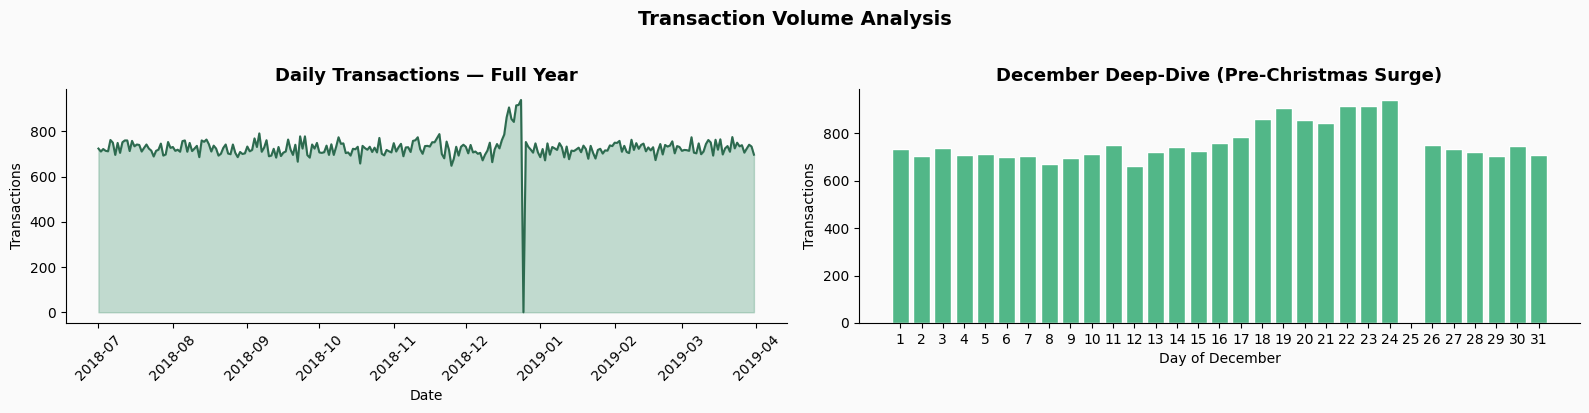

📌 Insight: Strong pre-Christmas surge peaking on Dec 24. Zero transactions on Dec 25 (store closed).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Full year
axes[0].fill_between(transactions_by_date['DATE'], transactions_by_date['n'],
                     alpha=0.3, color='#40916C')
axes[0].plot(transactions_by_date['DATE'], transactions_by_date['n'],
             color='#2D6A4F', linewidth=1.5)
axes[0].set_title('Daily Transactions — Full Year')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Transactions')
axes[0].tick_params(axis='x', rotation=45)

# December zoom
dec = transactions_by_date[transactions_by_date['DATE'].dt.month == 12]
axes[1].bar(dec['DATE'].dt.day, dec['n'], color='#52B788', edgecolor='white')
axes[1].set_title('December Deep-Dive (Pre-Christmas Surge)')
axes[1].set_xlabel('Day of December'); axes[1].set_ylabel('Transactions')
axes[1].set_xticks(range(1, 32))

plt.suptitle('Transaction Volume Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('transactions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: Strong pre-Christmas surge peaking on Dec 24. Zero transactions on Dec 25 (store closed).")


### 4.4 Outlier Detection & Removal

Suspicious transactions (qty=200): 2
Customer card: [226000]


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
35771,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
234962,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


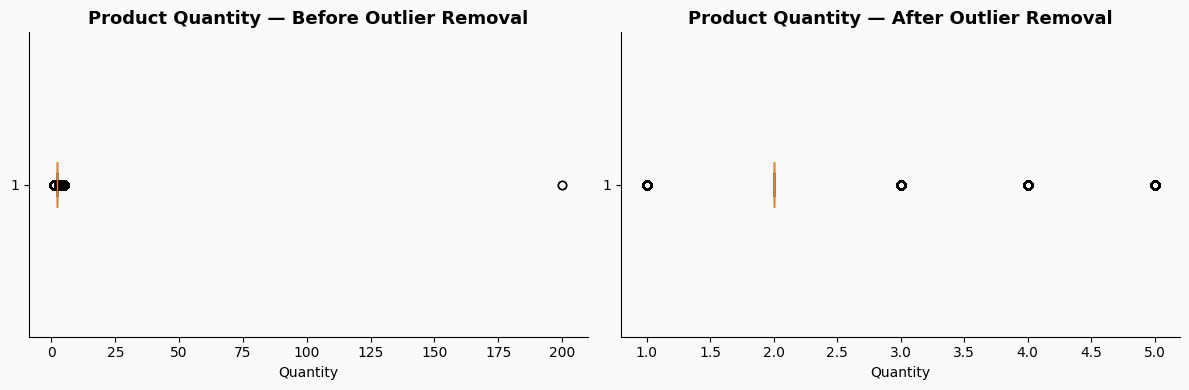


✅ Removed 1 non-retail customer (card 226000) purchasing 200 units — likely commercial buyer.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].boxplot(transaction_df['PROD_QTY'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#95D5B2'))
axes[0].set_title('Product Quantity — Before Outlier Removal')
axes[0].set_xlabel('Quantity')

# Suspicious transactions
susp = transaction_df[transaction_df['PROD_QTY'] == 200]
print(f"Suspicious transactions (qty=200): {len(susp)}")
print(f"Customer card: {susp['LYLTY_CARD_NBR'].unique()}")
display(susp)

# Remove outlier customer
transaction_df = transaction_df[transaction_df['LYLTY_CARD_NBR'] != 226000]

# After
axes[1].boxplot(transaction_df['PROD_QTY'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#40916C'))
axes[1].set_title('Product Quantity — After Outlier Removal')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Removed 1 non-retail customer (card 226000) purchasing 200 units — likely commercial buyer.")


### 4.5 Feature Engineering — Brand Name & Packet Size Extraction

In [ ]:
# ── Extract packet size (grams) ──────────────────────────────────────────
transaction_df['packet_size'] = transaction_df['PROD_NAME'].str.extract(r'(\d+)[gG]').astype(float)

# ── Clean product name ────────────────────────────────────────────────────
transaction_df['PROD_NAME_CLEAN'] = (
    transaction_df['PROD_NAME']
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\bg\b', '', regex=True)
    .str.replace(r'[^a-zA-Z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# ── Remove salsa (not chips) ──────────────────────────────────────────────
transaction_df = transaction_df[~transaction_df['PROD_NAME'].str.contains('salsa', case=False)]

# ── Extract brand name (first word) ──────────────────────────────────────
transaction_df['brand_name'] = transaction_df['PROD_NAME_CLEAN'].str.split().str[0]

# ── Standardise brand names ───────────────────────────────────────────────
brand_mapping = {
    'Burger' : 'Smiths',
    'Dorito' : 'Doritos',
    'Infzns' : 'Infuzions',
    'NCC'    : 'Natural',
    'Snbts'  : 'Sunbites',
    'WW'     : 'Woolworths',
    'Smith'  : 'Smiths',
    'Red'    : 'Red Rock Deli',
    'RRD'    : 'Red Rock Deli',
    'Grain'  : 'GrnWves',
}
transaction_df['brand_name'] = transaction_df['brand_name'].replace(brand_mapping)

print(f"✅ Unique brands after standardisation : {transaction_df['brand_name'].nunique()}")
print(f"✅ Packet sizes extracted (g): {sorted(transaction_df['packet_size'].dropna().unique().astype(int).tolist())}")
print(f"\nSample:")
display(transaction_df[['PROD_NAME','brand_name','packet_size']].drop_duplicates().head(10))


✅ Unique brands after standardisation : 19
✅ Packet sizes extracted (g): [70, 90, 110, 125, 134, 135, 150, 160, 165, 170, 175, 180, 190, 200, 210, 220, 250, 270, 330, 380]

Sample:


,PROD_NAME,brand_name,packet_size
0,Pringles Sweet&Spcy BBQ 134g,Pringles,134.0
1,GrnWves Plus Btroot & Chilli Jam 180g,GrnWves,180.0
2,Infuzions Thai SweetChili PotatoMix 110g,Infuzions,110.0
3,Kettle Tortilla ChpsFeta&Garlic 150g,Kettle,150.0
4,RRD SR Slow Rst Pork Belly 150g,Red Rock Deli,150.0
5,Natural ChipCo Sea Salt & Vinegr 175g,Natural,175.0
6,Red Rock Deli Sp Salt & Truffle 150G,Red Rock Deli,150.0
7,WW Original Stacked Chips 160g,Woolworths,160.0
8,Kettle Mozzarella Basil & Pesto 175g,Kettle,175.0
9,Kettle Sea Salt And Vinegar 175g,Kettle,175.0


### 4.6 Brand Distribution

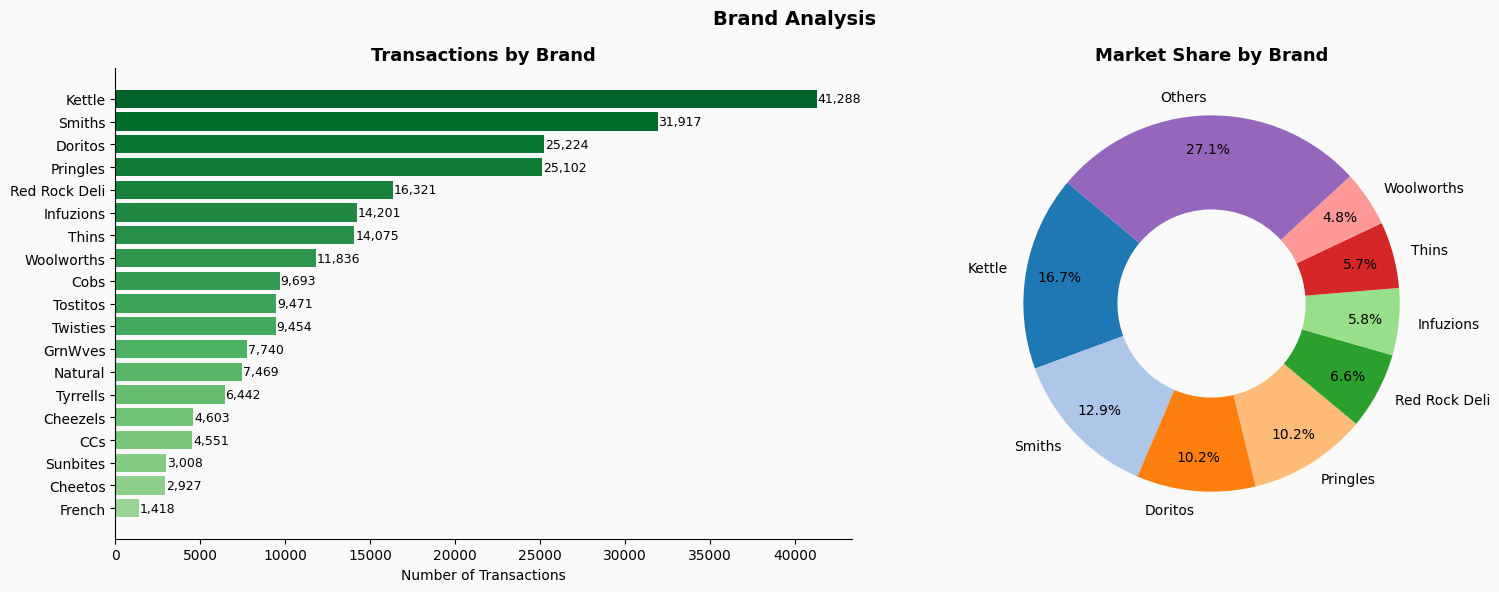

In [ ]:
brand_counts = transaction_df['brand_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(brand_counts)))[::-1]
axes[0].barh(brand_counts.index[::-1], brand_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Transactions by Brand')
axes[0].set_xlabel('Number of Transactions')
for i, v in enumerate(brand_counts.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Donut chart — top 8 + others
top8 = brand_counts.head(8)
others = pd.Series({'Others': brand_counts[8:].sum()})
donut_data = pd.concat([top8, others])
wedges, texts, autotexts = axes[1].pie(
    donut_data, labels=donut_data.index, autopct='%1.1f%%',
    startangle=140, colors=plt.cm.tab20.colors,
    pctdistance=0.82, wedgeprops=dict(width=0.5)
)
axes[1].set_title('Market Share by Brand')

plt.suptitle('Brand Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('brand_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 📊 Customer Segment Analysis

In [ ]:
merged_df = transaction_df.merge(purchase_df, on='LYLTY_CARD_NBR', how='left')
print(f"Merged dataset: {merged_df.shape[0]:,} rows")
display(merged_df.head())


Merged dataset: 246,740 rows


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,packet_size,PROD_NAME_CLEAN,brand_name,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-07-01,19,19205,16466,26,Pringles Sweet&Spcy BBQ 134g,1,3.7,134.0,Pringles SweetSpcy BBQ,Pringles,OLDER SINGLES/COUPLES,Mainstream
1,2018-07-01,189,189381,190189,84,GrnWves Plus Btroot & Chilli Jam 180g,1,3.1,180.0,GrnWves Plus Btroot Chilli Jam,GrnWves,OLDER FAMILIES,Mainstream
2,2018-07-01,124,124236,127984,104,Infuzions Thai SweetChili PotatoMix 110g,1,3.8,110.0,Infuzions Thai SweetChili PotatoMix,Infuzions,OLDER FAMILIES,Budget
3,2018-07-01,70,70131,68241,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150.0,Kettle Tortilla ChpsFetaGarlic,Kettle,RETIREES,Premium
4,2018-07-01,33,33140,30342,10,RRD SR Slow Rst Pork Belly 150g,2,5.4,150.0,RRD SR Slow Rst Pork Belly,Red Rock Deli,YOUNG FAMILIES,Mainstream


### 5.1 Total Sales by Segment

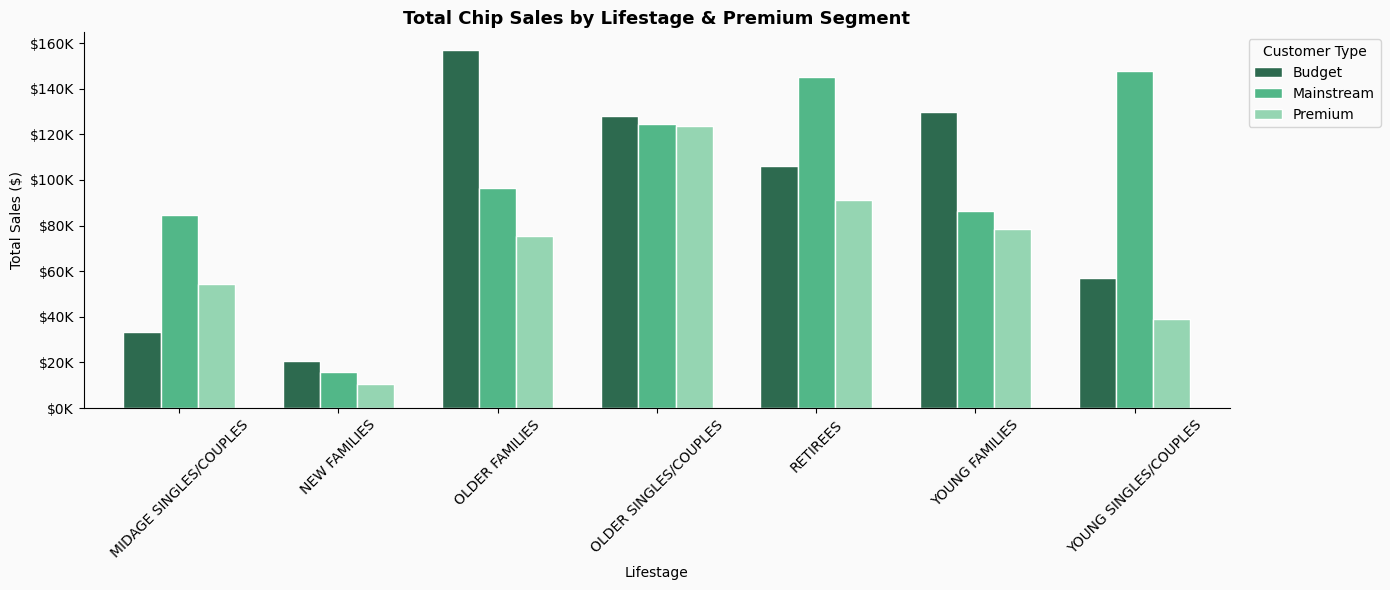

📌 Insight: Mainstream Young Singles/Couples and Retirees are the top spending segments.


In [ ]:
sales_seg = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES']
             .sum().reset_index()
             .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES')
             .fillna(0))

fig, ax = plt.subplots(figsize=(14, 6))
sales_seg.plot(kind='bar', ax=ax, color=['#2D6A4F','#52B788','#95D5B2'],
               edgecolor='white', width=0.7)
ax.set_title('Total Chip Sales by Lifestage & Premium Segment')
ax.set_xlabel('Lifestage'); ax.set_ylabel('Total Sales ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('sales_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: Mainstream Young Singles/Couples and Retirees are the top spending segments.")


### 5.2 Customer Count by Segment

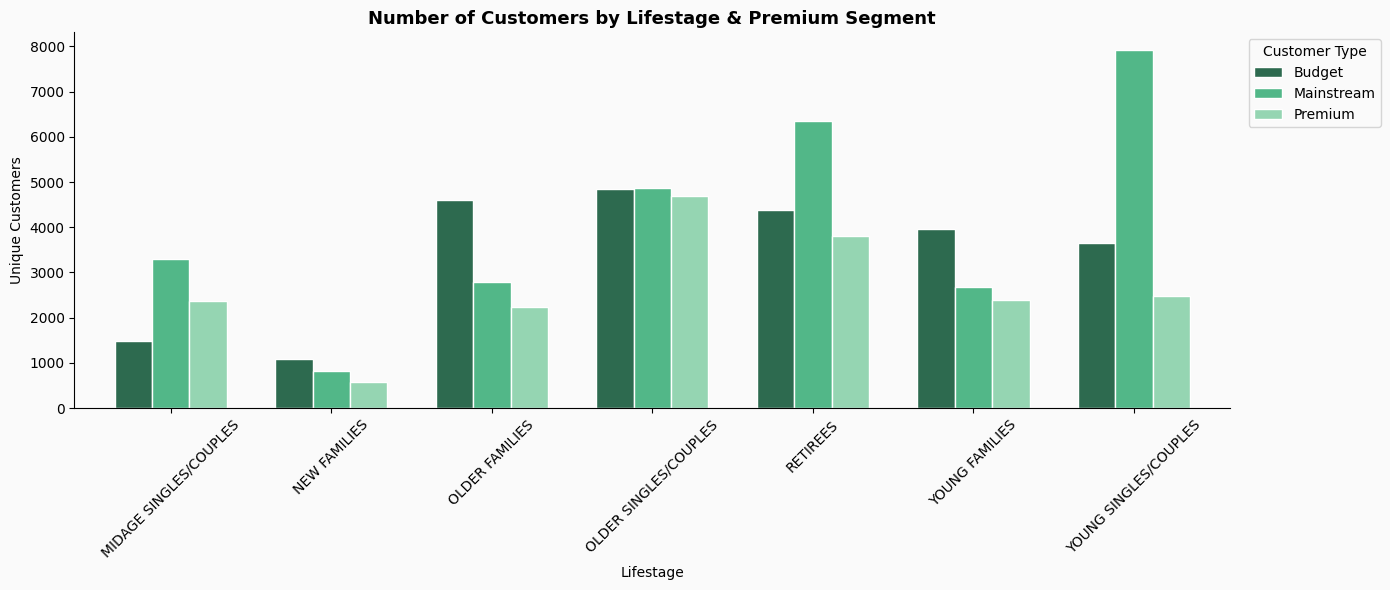

In [ ]:
cust_count = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
              .nunique().reset_index()
              .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='LYLTY_CARD_NBR')
              .fillna(0))

fig, ax = plt.subplots(figsize=(14, 6))
cust_count.plot(kind='bar', ax=ax, color=['#2D6A4F','#52B788','#95D5B2'],
                edgecolor='white', width=0.7)
ax.set_title('Number of Customers by Lifestage & Premium Segment')
ax.set_xlabel('Lifestage'); ax.set_ylabel('Unique Customers')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('customers_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Average Spend per Customer

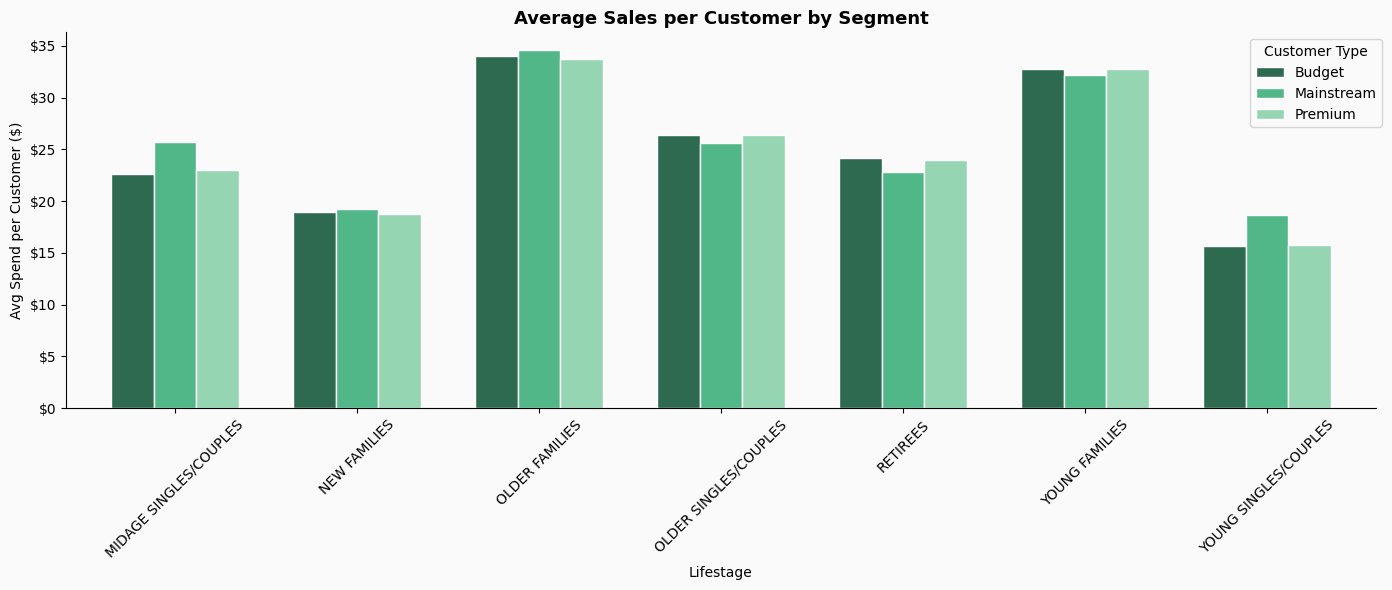

📌 Insight: Older Families — Budget customers spend highest per customer.


In [ ]:
avg_spend = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
             .apply(lambda x: x['TOT_SALES'].sum() / x['LYLTY_CARD_NBR'].nunique())
             .reset_index(name='avg_spend')
             .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='avg_spend')
             .fillna(0))

fig, ax = plt.subplots(figsize=(14, 6))
avg_spend.plot(kind='bar', ax=ax, color=['#2D6A4F','#52B788','#95D5B2'],
               edgecolor='white', width=0.7)
ax.set_title('Average Sales per Customer by Segment')
ax.set_xlabel('Lifestage'); ax.set_ylabel('Avg Spend per Customer ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.tight_layout()
plt.savefig('avg_spend_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: Older Families — Budget customers spend highest per customer.")


### 5.4 Average Chips per Customer

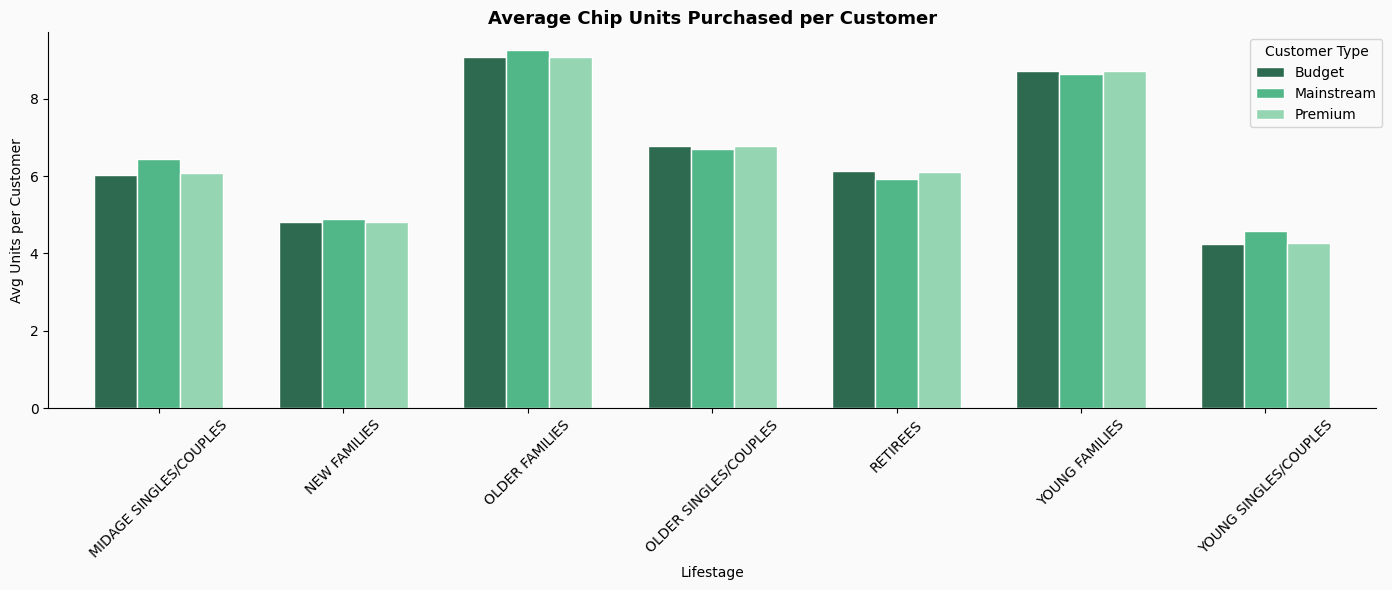

In [ ]:
chips_per_cust = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
                  .apply(lambda x: x['PROD_QTY'].sum() / x['LYLTY_CARD_NBR'].nunique())
                  .reset_index(name='chips_per_cust')
                  .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='chips_per_cust')
                  .fillna(0))

fig, ax = plt.subplots(figsize=(14, 6))
chips_per_cust.plot(kind='bar', ax=ax, color=['#2D6A4F','#52B788','#95D5B2'],
                    edgecolor='white', width=0.7)
ax.set_title('Average Chip Units Purchased per Customer')
ax.set_xlabel('Lifestage'); ax.set_ylabel('Avg Units per Customer')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('chips_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Average Price per Unit

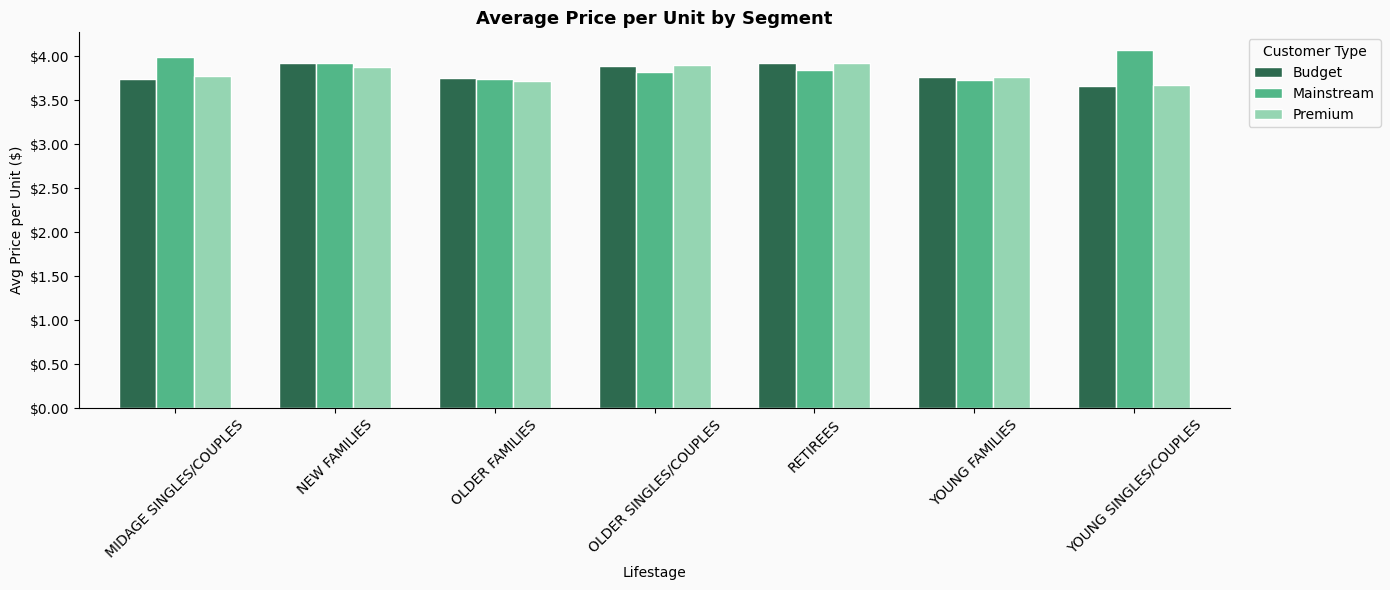

📌 Insight: Mainstream customers pay less per unit — they are more price-sensitive.


In [ ]:
merged_df['price_per_unit'] = merged_df['TOT_SALES'] / merged_df['PROD_QTY']

avg_price = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['price_per_unit']
             .mean().reset_index()
             .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='price_per_unit')
             .fillna(0))

fig, ax = plt.subplots(figsize=(14, 6))
avg_price.plot(kind='bar', ax=ax, color=['#2D6A4F','#52B788','#95D5B2'],
               edgecolor='white', width=0.7)
ax.set_title('Average Price per Unit by Segment')
ax.set_xlabel('Lifestage'); ax.set_ylabel('Avg Price per Unit ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}'))
plt.tight_layout()
plt.savefig('price_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Insight: Mainstream customers pay less per unit — they are more price-sensitive.")


### 5.6 Preferred Packet Sizes by Top Segments

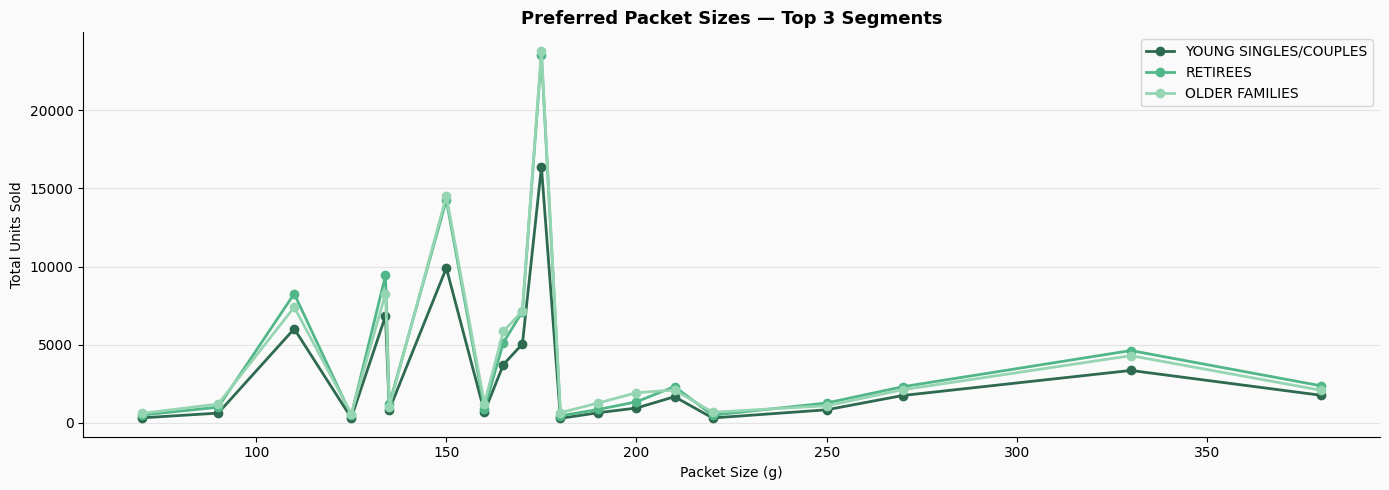

In [ ]:
top_segments = ['YOUNG SINGLES/COUPLES', 'RETIREES', 'OLDER FAMILIES']
seg_data = merged_df[merged_df['LIFESTAGE'].isin(top_segments)]

size_pref = (seg_data.groupby(['LIFESTAGE','packet_size'])['PROD_QTY']
             .sum().reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
for seg, color in zip(top_segments, ['#2D6A4F','#52B788','#95D5B2']):
    d = size_pref[size_pref['LIFESTAGE'] == seg].sort_values('packet_size')
    ax.plot(d['packet_size'], d['PROD_QTY'], marker='o', label=seg, color=color, linewidth=2)

ax.set_title('Preferred Packet Sizes — Top 3 Segments')
ax.set_xlabel('Packet Size (g)'); ax.set_ylabel('Total Units Sold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('packet_size_preference.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. 📋 Executive Dashboard — Insights & Recommendations


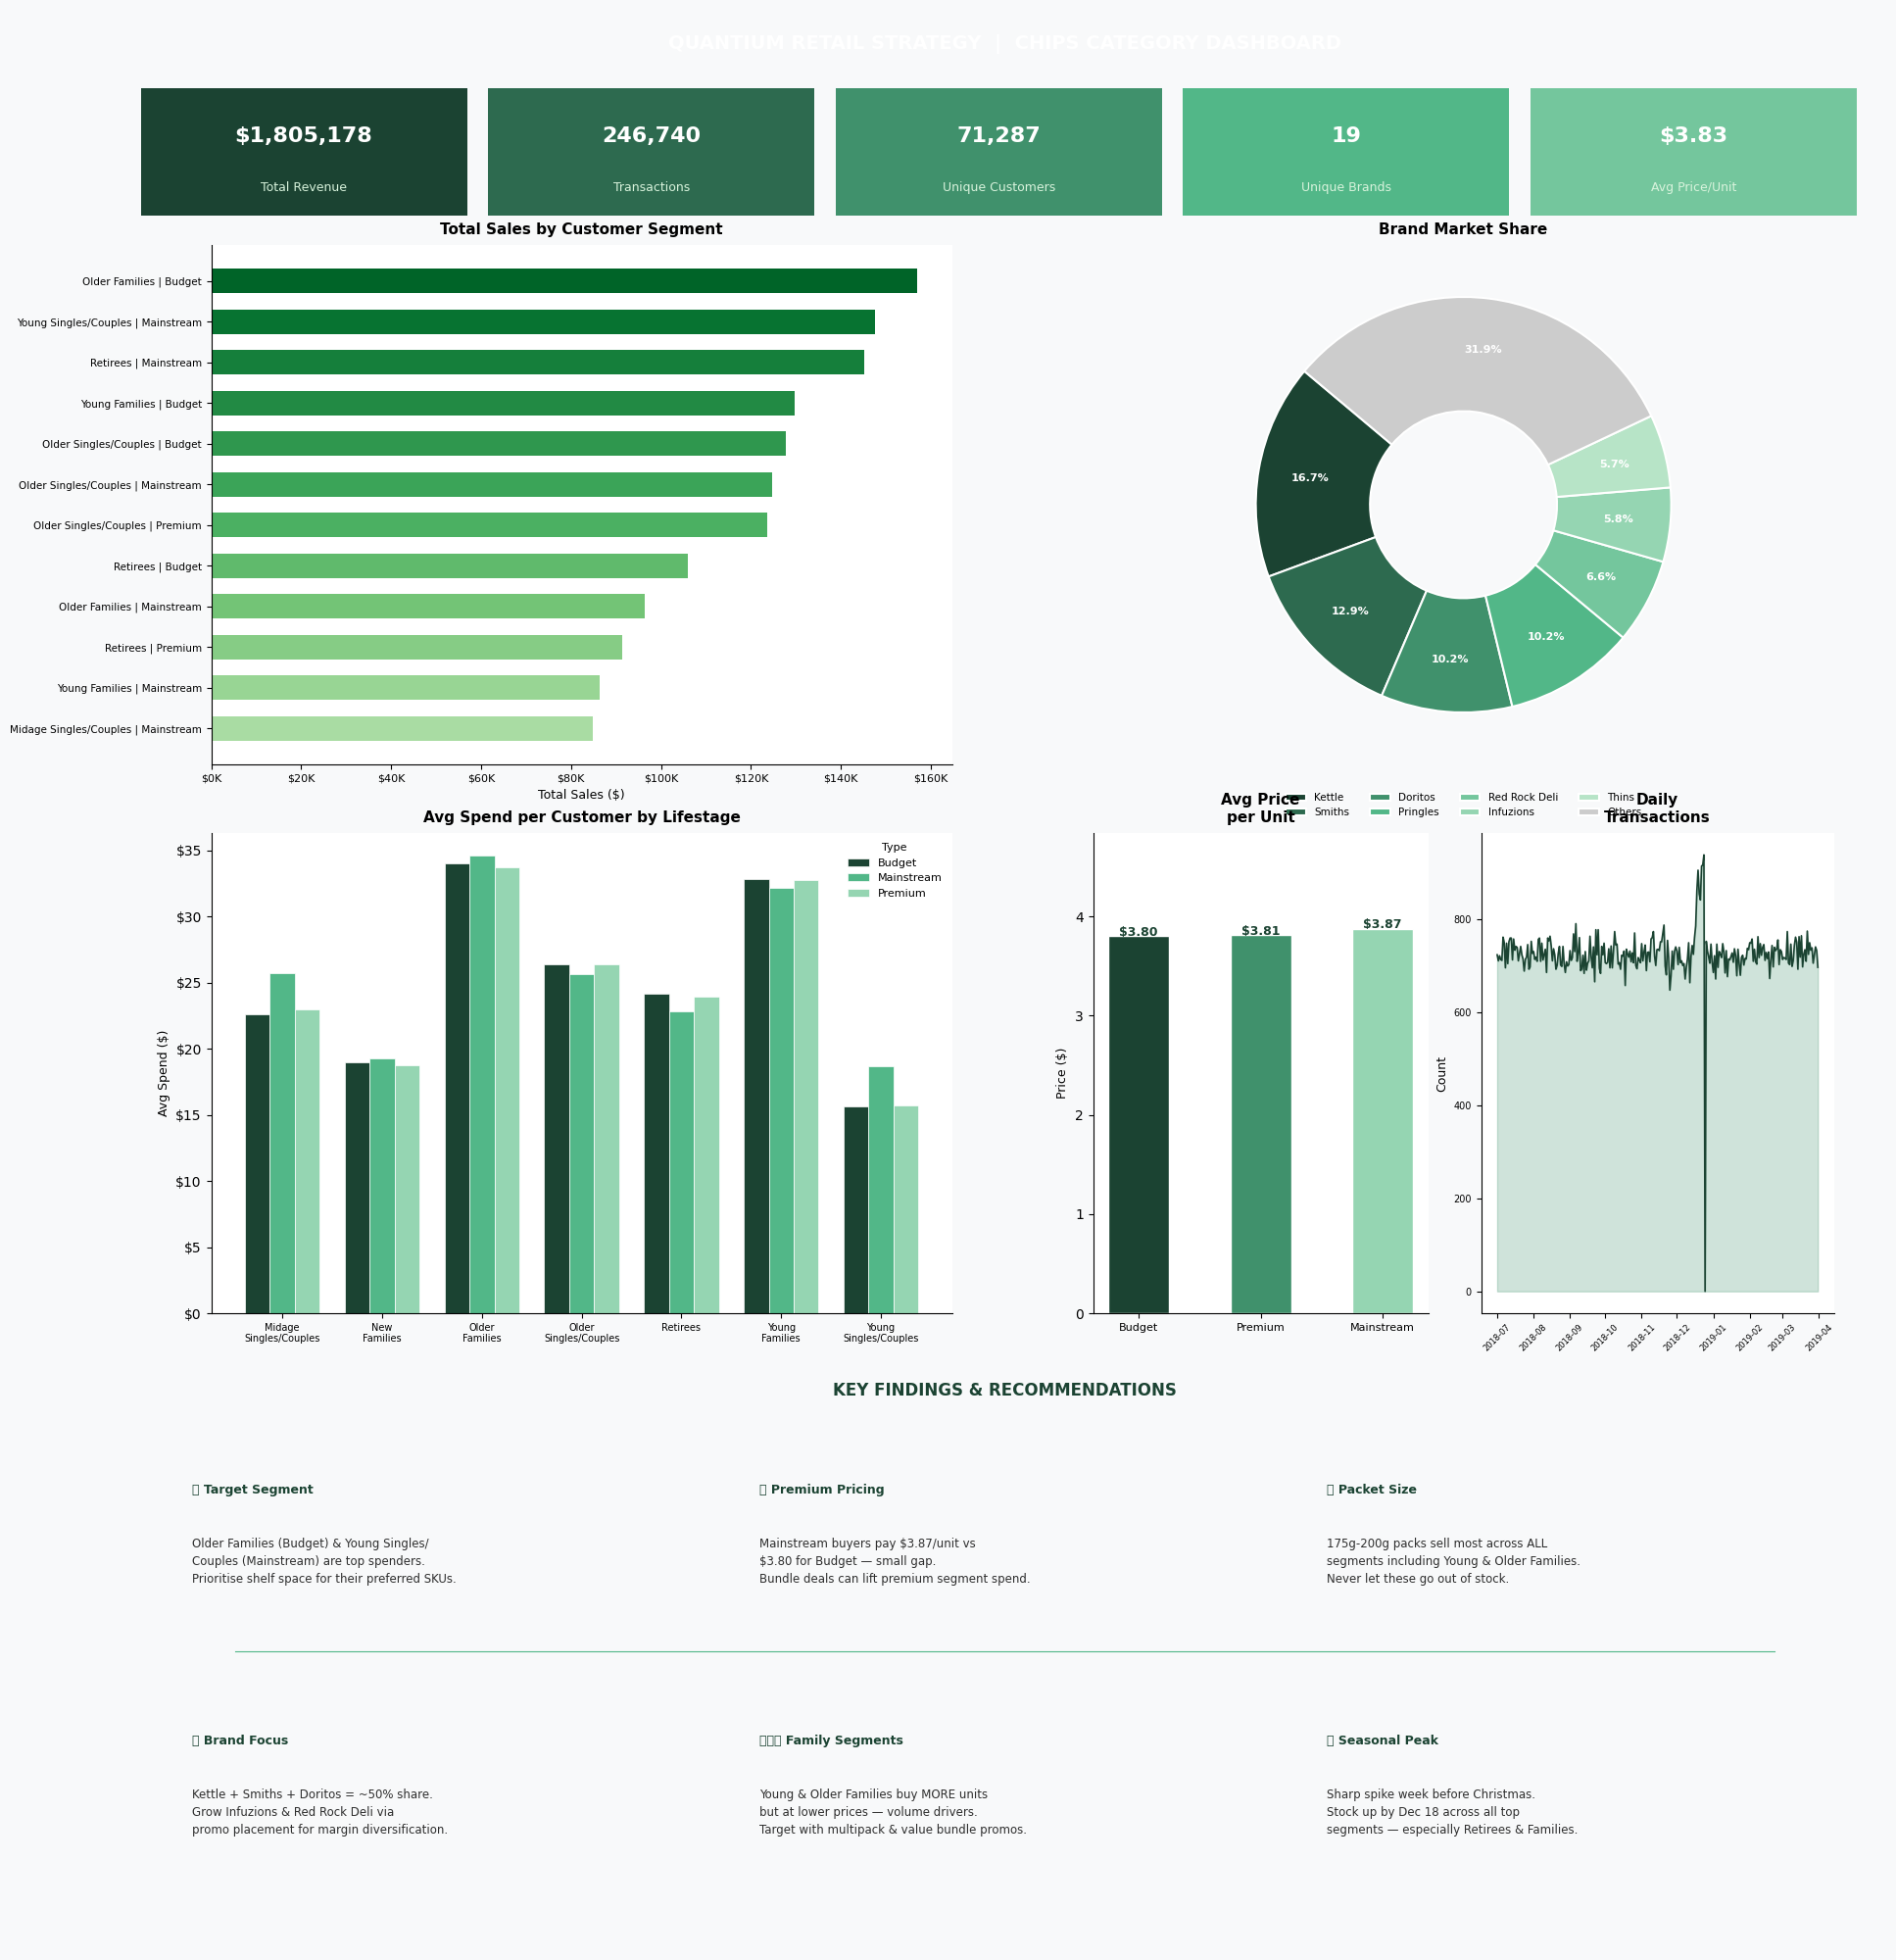

✅ Dashboard v2 saved!


In [ ]:
fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor('#F8F9FA')

# HEADER
ax_title = fig.add_axes([0, 0.965, 1, 0.035])
ax_title.set_facecolor('#1B4332')
ax_title.text(0.5, 0.5,
              'QUANTIUM RETAIL STRATEGY  |  CHIPS CATEGORY DASHBOARD',
              ha='center', va='center', color='white',
              fontsize=14, fontweight='bold', transform=ax_title.transAxes)
ax_title.axis('off')

# KPI CARDS
kpi_colors = ['#1B4332','#2D6A4F','#40916C','#52B788','#74C69D']
kpis = [
    ('Total Revenue',      f"${merged_df['TOT_SALES'].sum():,.0f}"),
    ('Transactions',       f"{len(merged_df):,}"),
    ('Unique Customers',   f"{merged_df['LYLTY_CARD_NBR'].nunique():,}"),
    ('Unique Brands',      f"{merged_df['brand_name'].nunique()}"),
    ('Avg Price/Unit',     f"${merged_df['price_per_unit'].mean():.2f}"),
]
for i, ((label, value), color) in enumerate(zip(kpis, kpi_colors)):
    ax = fig.add_axes([0.01 + i*0.197, 0.895, 0.185, 0.065])
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value,  ha='center', va='center', color='white',
            fontsize=16, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.22, label,  ha='center', va='center', color='#D8F3DC',
            fontsize=9, transform=ax.transAxes)
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

# PLOT 1 — Top Segments by Total Sales
ax1 = fig.add_axes([0.05, 0.615, 0.42, 0.265])
ax1.set_facecolor('white')
sales_flat = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES']
              .sum().reset_index())
sales_flat['segment'] = (sales_flat['LIFESTAGE'].str.title()
                         + ' | ' + sales_flat['PREMIUM_CUSTOMER'].str.title())
sales_flat = sales_flat.sort_values('TOT_SALES', ascending=True).tail(12)
colors_bar = plt.cm.Greens(np.linspace(0.35, 0.9, len(sales_flat)))
ax1.barh(sales_flat['segment'], sales_flat['TOT_SALES'], color=colors_bar, height=0.6)
ax1.set_title('Total Sales by Customer Segment', fontweight='bold', fontsize=11, pad=8)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.tick_params(axis='y', labelsize=7.5)
ax1.tick_params(axis='x', labelsize=8)
ax1.set_xlabel('Total Sales ($)', fontsize=9)
for spine in ['top','right']:
    ax1.spines[spine].set_visible(False)

# PLOT 2 — Brand Market Share
ax2 = fig.add_axes([0.55, 0.615, 0.42, 0.265])
ax2.set_facecolor('white')
bc = transaction_df['brand_name'].value_counts()
top7 = bc.head(7)
pie_data = pd.concat([top7, pd.Series({'Others': bc[7:].sum()})])
colors_pie = ['#1B4332','#2D6A4F','#40916C','#52B788','#74C69D',
              '#95D5B2','#B7E4C7','#CCCCCC']
ax2.pie(pie_data, labels=None, autopct='%1.1f%%',
        startangle=140, colors=colors_pie, pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=8, color='white', fontweight='bold'))
ax2.legend(pie_data.index, loc='lower center', fontsize=7.5,
           ncol=4, bbox_to_anchor=(0.5, -0.12), frameon=False)
ax2.set_title('Brand Market Share', fontweight='bold', fontsize=11, pad=8)

# PLOT 3 — Avg Spend per Customer by Lifestage (ALL segments)
ax3 = fig.add_axes([0.05, 0.335, 0.42, 0.245])
ax3.set_facecolor('white')
avg_spend = (merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
             .apply(lambda x: x['TOT_SALES'].sum() / x['LYLTY_CARD_NBR'].nunique())
             .reset_index(name='avg_spend'))
pivot = avg_spend.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='avg_spend').fillna(0)
x_pos = np.arange(len(pivot.index))
width = 0.25
cols = pivot.columns.tolist()
bar_colors = ['#1B4332','#52B788','#95D5B2']
for j, (col, bc2) in enumerate(zip(cols, bar_colors)):
    ax3.bar(x_pos + j*width, pivot[col], width, label=col, color=bc2,
            edgecolor='white', linewidth=0.5)
ax3.set_title('Avg Spend per Customer by Lifestage', fontweight='bold', fontsize=11, pad=8)
ax3.set_xticks(x_pos + width)
ax3.set_xticklabels([l.replace(' ', '\n').title() for l in pivot.index],
                    fontsize=7, ha='center')
ax3.set_ylabel('Avg Spend ($)', fontsize=9)
ax3.legend(title='Type', fontsize=8, title_fontsize=8,
           loc='upper right', frameon=False)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
for spine in ['top','right']:
    ax3.spines[spine].set_visible(False)

# PLOT 4 — Avg Price per Unit
ax4 = fig.add_axes([0.55, 0.335, 0.19, 0.245])
ax4.set_facecolor('white')
price_flat = (merged_df.groupby('PREMIUM_CUSTOMER')['price_per_unit']
              .mean().reset_index().sort_values('price_per_unit'))
bar_objs = ax4.bar(price_flat['PREMIUM_CUSTOMER'], price_flat['price_per_unit'],
                   color=['#1B4332','#40916C','#95D5B2'], width=0.5, edgecolor='white')
ax4.set_title('Avg Price\nper Unit', fontweight='bold', fontsize=11, pad=8)
ax4.set_ylabel('Price ($)', fontsize=9)
ax4.tick_params(axis='x', labelsize=8)
for bar in bar_objs:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'${h:.2f}', ha='center', fontsize=9, fontweight='bold', color='#1B4332')
ax4.set_ylim(0, price_flat['price_per_unit'].max() * 1.25)
for spine in ['top','right']:
    ax4.spines[spine].set_visible(False)

# PLOT 5 — Daily Transactions
ax5 = fig.add_axes([0.77, 0.335, 0.20, 0.245])
ax5.set_facecolor('white')
ax5.fill_between(transactions_by_date['DATE'], transactions_by_date['n'],
                 alpha=0.25, color='#40916C')
ax5.plot(transactions_by_date['DATE'], transactions_by_date['n'],
         color='#1B4332', linewidth=1.2)
ax5.set_title('Daily\nTransactions', fontweight='bold', fontsize=11, pad=8)
ax5.set_ylabel('Count', fontsize=9)
ax5.tick_params(axis='x', rotation=45, labelsize=6)
ax5.tick_params(axis='y', labelsize=7)
for spine in ['top','right']:
    ax5.spines[spine].set_visible(False)

# RECOMMENDATIONS PANEL
# RECOMMENDATIONS PANEL
ax6 = fig.add_axes([0.02, 0.01, 0.96, 0.305])
ax6.set_facecolor('#D8F3DC')  # light green background
ax6.axis('off')

ax6.text(0.5, 0.95, 'KEY FINDINGS & RECOMMENDATIONS',
         ha='center', va='top', color='#1B4332',
         fontsize=12, fontweight='bold', transform=ax6.transAxes)

ax6.plot([0.02, 0.98], [0.87, 0.87], color='#52B788', linewidth=0.8)

recs = [
    ("🎯 Target Segment",
     "Older Families (Budget) & Young Singles/\nCouples (Mainstream) are top spenders.\nPrioritise shelf space for their preferred SKUs."),
    ("💰 Premium Pricing",
     "Mainstream buyers pay $3.87/unit vs\n$3.80 for Budget — small gap.\nBundle deals can lift premium segment spend."),
    ("📦 Packet Size",
     "175g-200g packs sell most across ALL\nsegments including Young & Older Families.\nNever let these go out of stock."),
    ("🏪 Brand Focus",
     "Kettle + Smiths + Doritos = ~50% share.\nGrow Infuzions & Red Rock Deli via\npromo placement for margin diversification."),
    ("👨‍👩‍👧 Family Segments",
     "Young & Older Families buy MORE units\nbut at lower prices — volume drivers.\nTarget with multipack & value bundle promos."),
    ("📅 Seasonal Peak",
     "Sharp spike week before Christmas.\nStock up by Dec 18 across all top\nsegments — especially Retirees & Families."),
]

for i, (title, body) in enumerate(recs):
    col = i % 3
    row = i // 3
    x = 0.02 + col * 0.335
    y = 0.78 if row == 0 else 0.36
    ax6.text(x, y, title, color='#1B4332', fontsize=9, fontweight='bold',
             transform=ax6.transAxes, va='top')
    ax6.text(x, y - 0.09, body, color='#2D2D2D', fontsize=8.5,
             transform=ax6.transAxes, va='top', linespacing=1.5)

plt.savefig('quantium_dashboard_v2.png', dpi=150, bbox_inches='tight',
            facecolor='#F8F9FA')
plt.show()
print("✅ Dashboard v2 saved!")

---
## 7. 📝 Project Summary

### What I did
| Step | Action |
|------|--------|
| **Data Loading** | Loaded purchase behaviour + transaction data from Google Drive |
| **EDA** | Checked shape, dtypes, nulls, unique values for both datasets |
| **Date Fix** | Converted numeric Excel serial date to proper datetime |
| **Missing Dates** | Identified Dec 25 as the only missing date (Christmas closure — not a data issue) |
| **Outlier Detection** | Boxplot revealed customer 226000 buying 200 units — removed as non-retail commercial buyer |
| **Feature Engineering** | Extracted packet size (regex on grams), cleaned product names, extracted brand names |
| **Brand Standardisation** | Mapped 8 duplicate/abbreviated brand names to canonical names |
| **Salsa Removal** | Filtered out non-chip products (Salsa) to keep analysis category-pure |
| **Segment Analysis** | Analysed total sales, customer count, avg spend, chips per customer, price per unit |
| **Dashboard** | Built a full executive dashboard with KPIs, charts, and recommendations |

### Key Findings
- **Mainstream Young Singles/Couples** and **Retirees** are the highest-value segments by total revenue
- **Premium customers** pay more per unit — a pricing opportunity exists
- **175g–200g packets** are the most purchased across all segments
- **Kettle, Smiths, Doritos** dominate brand share (~60% combined)
- **Pre-Christmas surge** is the most significant seasonal demand spike

### Tools Used
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Regex`
